# Stock et al. 2008

So the general Structure is

N -> P1, P2, P3 -> Z1, Z2, Z3, Z4 -> higher order mortality

Basically, I can use the Banas setup, and then adjust the equations and number of P and Z

### visualize grazing on Z and P

In [13]:
def grazing_test(resource, consumer, phiPZ, Imax, KsZ):
    """Here we are using a matrix calculation, to define the pair-wise interaction."""
    biomass = np.concatenate((resource, consumer))
    #print(biomass)
    graz_pref = phiPZ.T * (np.transpose((biomass * phiPZ)**2)/np.sum((biomass * phiPZ)**2, axis=1))**0.5
    #print("graz_pref",graz_pref)

    BMscaledAsFood = np.transpose(biomass * graz_pref.T)
    #print("BMscaledAsFood", BMscaledAsFood)
    FgrazP = Imax * BMscaledAsFood / (KsZ + np.sum(BMscaledAsFood, axis=0))
    #print("FgrazP", FgrazP)
    return FgrazP * consumer

In [32]:
# import necessary packages
import numpy as np
import matplotlib.pyplot as plt
import xso

In [33]:
iarr = np.linspace(0.01,6,50)
jarr = np.linspace(0.01,6,50)
output = np.zeros((len(iarr),len(jarr)))

for i in range(len(iarr)):
    for j in range(len(jarr)):
        phyto_init = np.array([1,1,iarr[i]])
        zoo_init = np.array([1,jarr[j],1,1])
        out = np.sum(grazing_test(phyto_init, zoo_init, zoo_prey_avail, zoo_imax, zoo_Ki), axis=0)[2]
        output[i,j] = out

#outputarr = np.array(output)

NameError: name 'grazing_test' is not defined

Text(0.5, 0, 'phyto')

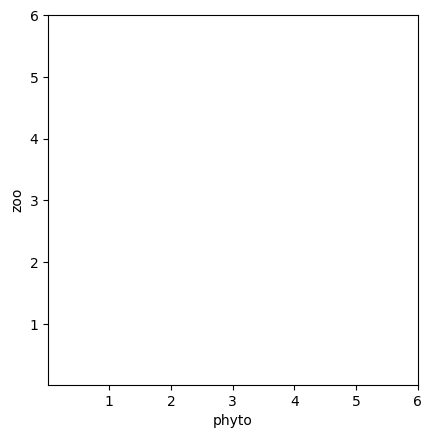

In [34]:
fig, ax = plt.subplots()
CS = ax.contour(iarr,jarr,output/1.1)
ax.clabel(CS, fontsize=10)
ax.set_aspect(1)
ax.set_ylabel("zoo")
ax.set_xlabel("phyto")

# Import components and create model

In [35]:
from Stocketal2008_comps import (Nutrient, PhytoSizeSpectrum, ZooSizeSpectrum, 
    ConstantExternalNutrient, LinearForcingInput, 
    MonodGrowth_SizeBased, 
    StockGrazingMatrix, Stock_GGE_MatrixGrazing, 
    StockPhytoMortality, StockZooMortality)

In [38]:
Stocketal2008 = xso.create({
    # State variables
    'Nutrient': Nutrient,
    'Phytoplankton': PhytoSizeSpectrum,
    'Zooplankton': ZooSizeSpectrum,

    # Flows:
    'Inflow': LinearForcingInput,

    # Growth
    'Growth': MonodGrowth_SizeBased,

    # Grazing
    'Grazing': StockGrazingMatrix,
    'GGE': Stock_GGE_MatrixGrazing,

    # Mortality
    'PhytoMortality': StockPhytoMortality,
    'HigherOrderMortality': StockZooMortality,

    # Forcings
    'N0': ConstantExternalNutrient,
})

In [39]:
Stocketal2008

<xsimlab.Model (13 processes, 42 inputs)>
Core
    solver_type              [in] solver type to use for model
Time
    time_input               [in] ('time',) sequence of time for wh...
Nutrient
    value_label              [in] label / nutrient concentration
    value_init               [in] initial value / nutrient concentr...
Phytoplankton
    biomass_label            [in] label / phytoplankton biomass
    biomass_init             [in] ('phyto',) initial value / phytop...
    phyto_index              [in] ('phyto',) index / size spectrum ...
Zooplankton
    biomass_label            [in] label / zooplankton biomass
    biomass_init             [in] ('zoo',) initial value / zooplank...
    zoo_index                [in] ('zoo',) index / size spectrum of...
N0
    forcing_label            [in] label / external nutrient
    value                    [in] parameter / constant value
Inflow
    var                      [in] label reference / variable affect...
    forcing                  [i

In [40]:
# number size classes of phytoplankton and zooplankton
P_num = 3
Z_num = 4

# create initial biomass
phyto_init = np.tile(1.5, (P_num))
zoo_init = np.tile(.1, (Z_num))

# calculate log-spaced size classes from ranges and total number
phyto_sizes = [0.63, 6.3, 63]
zoo_sizes = [6.3, 63, 630, 6300]

# Phytoplankton parameters
phyto_ks = [0.062, 0.45, 3.3]
phyto_mu0 = [1.0, 1.26, 0.42]
phyto_mortality = [1.0, 0, 0]
phyto_mort_exponent = [2.0, 1.0, 1.0]
phyto_recycling = [1.0, 0.0, 0.0]

# Zooplankton parameters
zoo_imax = [10.0, 3.3, 1.1, 0.36]
zoo_Ki = 3.0
zoo_frac_assim = 0.7  # alpha
zoo_frac_excreted = 0.45  # R
zoo_gge = 0.25
# prey availability: basically just 1 for size class below of Z and P, no other grazing! issa matrix 4 x 7
zoo_prey_avail = np.array([[1, 0, 0, 0, 0, 0, 0], # Z1
                          [0, 1, 0, 1, 0, 0, 0], # Z2
                          [0, 0, 1, 0, 1, 0, 0], # Z3
                          [0, 0, 0, 0, 0, 1, 0]]) # Z4

# dens dep prey exploitation factor
zoo_frac_egest_recycled = [1, 1, 0, 0]

# zoo mortality
zoo_higherordermortality = 0.0093
zoo_mortality_array = [0, 0, 0, zoo_higherordermortality]
zoo_mort_exponent = [0, 0, 0, 1]
zoo_frac_mortylity_recycled = [0, 0, 0, 0.5]



nutrient_input = 0.017

In [41]:
model_setup = xso.setup(solver='solve_ivp', model=Stocketal2008,
            time=np.arange(0,5000),
            input_vars={
                    # State variables
                    'Nutrient':{'value_label':'N','value_init':1.0},
                    'Phytoplankton':{'biomass_label':'P','biomass_init':phyto_init, 'phyto_index':phyto_sizes},
                 
                    'Zooplankton':{'biomass_label':'Z','biomass_init':zoo_init, 'zoo_index': zoo_sizes},
                
                    # Flows:
                    'Inflow':{'forcing':'N0', 'rate':1., 'var':'N'},
                
                    # Growth
                    'Growth':{'resource':'N', 'consumer':'P', 'halfsat':phyto_ks, 'mu_max':phyto_mu0},

                    # Grazing
                    'Grazing':{'resource':'P', 'consumer':'Z', 'Imax':zoo_imax, 'KsZ':zoo_Ki, 'phiPZ':zoo_prey_avail},
                    'GGE':{'grazed_phyto':'P', 'grazed_zoo':'Z', 'assimilated_consumer':'Z', 'egested_detritus':'N', 
                           'R':zoo_frac_excreted, 'alpha':zoo_frac_assim, 'f_I':zoo_frac_egest_recycled, 'gge':zoo_gge},
                
                    # Mortality
                    'PhytoMortality':{'population':'P', 'nutrient':'N', 'rate':phyto_mortality, 'exponent':phyto_mort_exponent, 'recycling':phyto_recycling},
                    'HigherOrderMortality':{'population':'Z', 'nutrient':'N', 'rate':zoo_mortality_array, 'exponent':zoo_mort_exponent, 'recycling':zoo_frac_mortylity_recycled},

                    # Forcings
                    'N0':{'forcing_label':'N0', 'value':nutrient_input},
            })

In [42]:
Stocketal2008

<xsimlab.Model (13 processes, 42 inputs)>
Core
    solver_type              [in] solver type to use for model
Time
    time_input               [in] ('time',) sequence of time for wh...
Nutrient
    value_label              [in] label / nutrient concentration
    value_init               [in] initial value / nutrient concentr...
Phytoplankton
    biomass_label            [in] label / phytoplankton biomass
    biomass_init             [in] ('phyto',) initial value / phytop...
    phyto_index              [in] ('phyto',) index / size spectrum ...
Zooplankton
    biomass_label            [in] label / zooplankton biomass
    biomass_init             [in] ('zoo',) initial value / zooplank...
    zoo_index                [in] ('zoo',) index / size spectrum of...
N0
    forcing_label            [in] label / external nutrient
    value                    [in] parameter / constant value
Inflow
    var                      [in] label reference / variable affect...
    forcing                  [i

In [43]:
with Stocketal2008:
        model_out = model_setup.xsimlab.run()

0.017
Model is assembled!
Model contains: 
Variables:['time', 'N', 'P', 'Z'] 
Parameters:['N0_value', 'Inflow_rate', 'Growth_halfsat', 'Growth_mu_max', 'Grazing_phiPZ', 'Grazing_Imax', 'Grazing_KsZ', 'HigherOrderMortality_rate', 'HigherOrderMortality_exponent', 'HigherOrderMortality_recycling', 'PhytoMortality_rate', 'PhytoMortality_exponent', 'PhytoMortality_recycling', 'GGE_gge', 'GGE_R', 'GGE_f_I', 'GGE_alpha'] 
Forcings:['N0'] 
Fluxes:['Time_time_flux', 'Inflow_input', 'Growth_uptake', 'Grazing_grazing', 'HigherOrderMortality_mortality', 'HigherOrderMortality_recycled_mortality', 'PhytoMortality_mortality', 'PhytoMortality_recycled_mortality', 'GGE_grazing_phyto', 'GGE_grazing_zoo', 'GGE_assimilation', 'GGE_recycled'] 
Full Model Dimensions:[('time', None), ('N', None), ('P', 3), ('Z', 4), ('Time_time_flux', None), ('Inflow_input', None), ('Growth_uptake', 3), ('Grazing_grazing', (7, 4)), ('HigherOrderMortality_mortality', 4), ('HigherOrderMortality_recycled_mortality', None), ('Ph

In [49]:
# plot nutrient:
model_out.Nutrient__value.plot(aspect=3, size=3, ylim=0)
# phytoplankton:
model_out.Phytoplankton__biomass.plot(yscale='log', aspect=3, size=3)
# zooplankton:
model_out.Zooplankton__biomass.plot(yscale='log', aspect=3, size=3)

NameError: name 'model_out_sinu' is not defined

# Test runs with sinusoidal nutrient influx

In [12]:
#time=np.arange(1,2000)

mean = 1
amplitude = 0.5
period = 365

def forcing(time):
    return mean + amplitude * np.sin(time / period * 2 * np.pi)

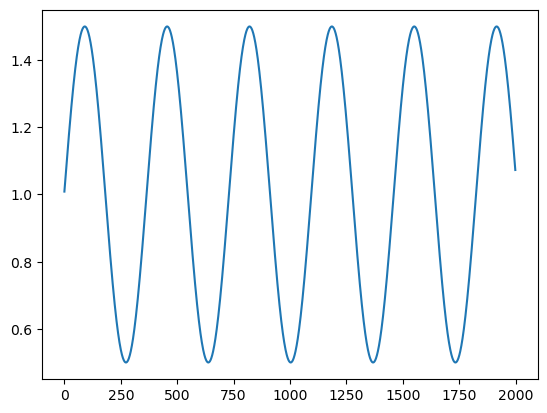

In [56]:
plt.plot(forcing(time))

In [37]:
@xso.component
class SinusoidalExternalNutrient:
    """Component that provides a sinusoidal forcing value.

    This component calculates a sinusoidal forcing value as a function of time, with a period
    defined by the `period` parameter. The forcing value is calculated as `cos(time / period * 2 * pi) + 1`.

    Attributes
    ----------
    forcing : xso.Forcing
        The XSO variable to define a forcing to be passed along to other components.
    period : xso.Parameter
        Defines the period of the sinusoidal forcing.

    Methods
    -------
    forcing_setup : function
        The function that defines the forcing value as a function of time.
    """
    forcing = xso.forcing(foreign=False, setup_func='forcing_setup', description='sinusoidal forcing')
    period = xso.parameter(description='period of sinusoidal forcing')
    amplitude = xso.parameter(description='amplitude of sinusoidal forcing')
    value = xso.variable(foreign=True, description='external nutrient value (mean in sinusoidal function)')

    def forcing_setup(self, period, value, amplitude):
        """Method that returns forcing function providing the
        forcing value as a function of time."""
        @np.vectorize
        def forcing(time):
            return value + amplitude * self.m.sin(time / period * 2 * self.m.pi)
        print(forcing(2))
        return forcing

@xso.component
class ConstantExternalNutrient:
    """Component that provides a constant external nutrient
     as a forcing value.
    """

    forcing = xso.forcing(foreign=False, setup_func='forcing_setup', description='external nutrient')
    value = xso.parameter(description='constant value')

    def forcing_setup(self, value):
        """Method that returns forcing function providing the
        forcing value as a function of time."""
        @np.vectorize
        def forcing(time):
            return value
        print(forcing(2))
        return forcing

In [28]:
Stocketal2008_sinusoidal = xso.create({
    # State variables
    'Nutrient': Nutrient,
    'Phytoplankton': PhytoSizeSpectrum,
    'Zooplankton': ZooSizeSpectrum,

    # Flows:
    'Inflow': LinearForcingInput,

    # Growth
    'Growth': MonodGrowth_SizeBased,

    # Grazing
    'Grazing': StockGrazingMatrix,
    'GGE': Stock_GGE_MatrixGrazing,

    # Mortality
    'PhytoMortality': StockPhytoMortality,
    'HigherOrderMortality': StockZooMortality,

    # Forcings
    'N0': SinusoidalExternalNutrient,
})

In [29]:
Stocketal2008_sinusoidal

<xsimlab.Model (13 processes, 44 inputs)>
Core
    solver_type              [in] solver type to use for model
Time
    time_input               [in] ('time',) sequence of time for wh...
Nutrient
    value_label              [in] label / nutrient concentration
    value_init               [in] initial value / nutrient concentr...
Phytoplankton
    biomass_label            [in] label / phytoplankton biomass
    biomass_init             [in] ('phyto',) initial value / phytop...
    phyto_index              [in] ('phyto',) index / size spectrum ...
Zooplankton
    biomass_label            [in] label / zooplankton biomass
    biomass_init             [in] ('zoo',) initial value / zooplank...
    zoo_index                [in] ('zoo',) index / size spectrum of...
N0
    forcing_label            [in] label / sinusoidal forcing
    period                   [in] parameter / period of sinusoidal ...
    amplitude                [in] parameter / amplitude of sinusoid...
    value                  

In [47]:
model_setup_sinusoidal = xso.setup(solver='solve_ivp', model=Stocketal2008_sinusoidal,
            time=np.arange(0,5000),
            input_vars={
                    # State variables
                    'Nutrient':{'value_label':'N','value_init':1.0},
                    'Phytoplankton':{'biomass_label':'P','biomass_init':phyto_init, 'phyto_index':phyto_sizes},
                 
                    'Zooplankton':{'biomass_label':'Z','biomass_init':zoo_init, 'zoo_index': zoo_sizes},
                
                    # Flows:
                    'Inflow':{'forcing':'N0', 'rate':1., 'var':'N'},
                
                    # Growth
                    'Growth':{'resource':'N', 'consumer':'P', 'halfsat':phyto_ks, 'mu_max':phyto_mu0},

                    # Grazing
                    'Grazing':{'resource':'P', 'consumer':'Z', 'Imax':zoo_imax, 'KsZ':zoo_Ki, 'phiPZ':zoo_prey_avail},
                    'GGE':{'grazed_phyto':'P', 'grazed_zoo':'Z', 'assimilated_consumer':'Z', 'egested_detritus':'N', 
                           'R':zoo_frac_excreted, 'alpha':zoo_frac_assim, 'f_I':zoo_frac_egest_recycled, 'gge':zoo_gge},
                
                    # Mortality
                    'PhytoMortality':{'population':'P', 'nutrient':'N', 'rate':phyto_mortality, 'exponent':phyto_mort_exponent, 'recycling':phyto_recycling},
                    'HigherOrderMortality':{'population':'Z', 'nutrient':'N', 'rate':zoo_mortality_array, 'exponent':zoo_mort_exponent, 'recycling':zoo_frac_mortylity_recycled},

                    # Forcings
                    'N0':{'forcing_label':'N0', 'value':nutrient_input, 'amplitude':0.01, 'period':365.0},
            })

In [48]:
with Stocketal2008_sinusoidal:
        model_out_sin = model_setup_sinusoidal.xsimlab.run()

0.017344216116227457
Model is assembled!
Model contains: 
Variables:['time', 'N', 'P', 'Z'] 
Parameters:['N0_period', 'N0_amplitude', 'Inflow_rate', 'Growth_halfsat', 'Growth_mu_max', 'Grazing_phiPZ', 'Grazing_Imax', 'Grazing_KsZ', 'HigherOrderMortality_rate', 'HigherOrderMortality_exponent', 'HigherOrderMortality_recycling', 'PhytoMortality_rate', 'PhytoMortality_exponent', 'PhytoMortality_recycling', 'GGE_gge', 'GGE_R', 'GGE_f_I', 'GGE_alpha'] 
Forcings:['N0'] 
Fluxes:['Time_time_flux', 'Inflow_input', 'Growth_uptake', 'Grazing_grazing', 'HigherOrderMortality_mortality', 'HigherOrderMortality_recycled_mortality', 'PhytoMortality_mortality', 'PhytoMortality_recycled_mortality', 'GGE_grazing_phyto', 'GGE_grazing_zoo', 'GGE_assimilation', 'GGE_recycled'] 
Full Model Dimensions:[('time', None), ('N', None), ('P', 3), ('Z', 4), ('Time_time_flux', None), ('Inflow_input', None), ('Growth_uptake', 3), ('Grazing_grazing', (7, 4)), ('HigherOrderMortality_mortality', 4), ('HigherOrderMortality_

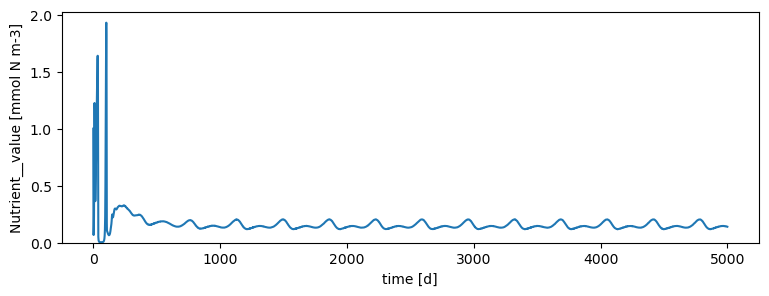

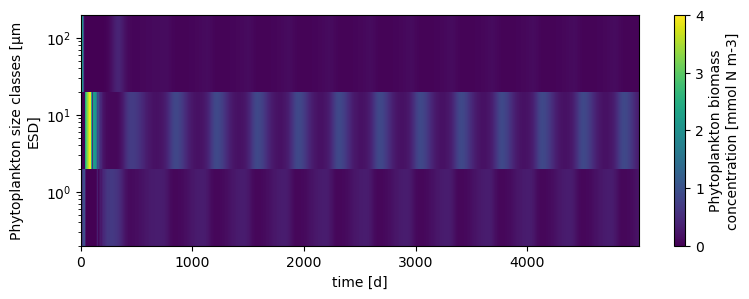

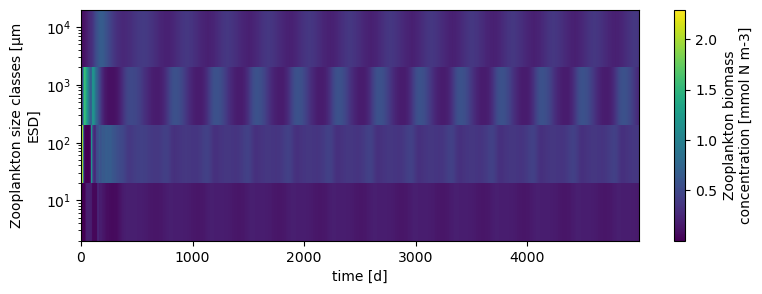

In [50]:
# plot nutrient:
model_out_sin.Nutrient__value.plot(aspect=3, size=3, ylim=0)
# phytoplankton:
model_out_sin.Phytoplankton__biomass.plot(yscale='log', aspect=3, size=3)
# zooplankton:
model_out_sin.Zooplankton__biomass.plot(yscale='log', aspect=3, size=3)

In [54]:
model_out_sin.Phytoplankton__biomass

<xarray.DataArray 'Phytoplankton__biomass' (phyto: 3, time: 5000)> Size: 120kB
array([[1.5       , 0.83582731, 0.4174276 , ..., 0.20410804, 0.20567782,
        0.20722651],
       [1.5       , 2.77578281, 3.16000904, ..., 0.29701269, 0.29348577,
        0.28998665],
       [1.5       , 1.55962073, 1.53651217, ..., 0.04867794, 0.04895949,
        0.04924197]])
Coordinates:
  * phyto    (phyto) float64 24B 0.63 6.3 63.0
  * time     (time) float64 40kB 0.0 1.0 2.0 ... 4.997e+03 4.998e+03 4.999e+03
Attributes:
    Phydra_store_out:  True
    description:       output of variable / phytoplankton biomass
    long_name:         Phytoplankton biomass concentration
    standard_name:     Phytoplankton
    units:             mmol N m-3

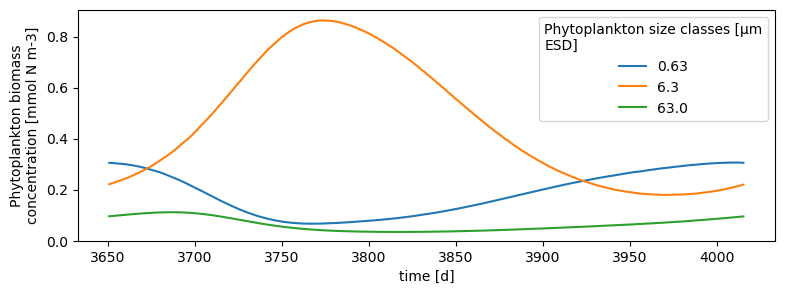

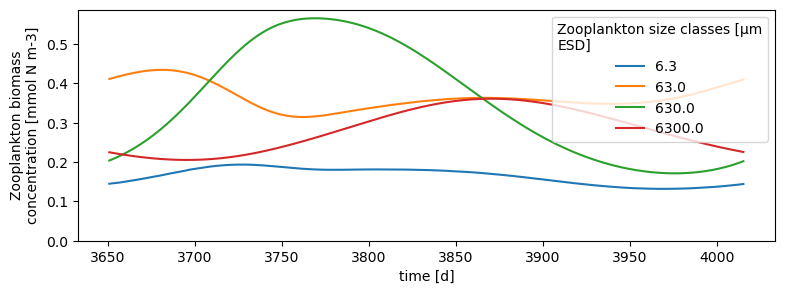

In [72]:
model_out_sin.Phytoplankton__biomass.sel(time=slice(365*10,365*11)).plot.line(x="time", aspect=3, size=3, ylim=0)
model_out_sin.Zooplankton__biomass.sel(time=slice(365*10,365*11)).plot.line(x="time", aspect=3, size=3, ylim=0)

In [ ]:
model_out_sin.Nutrient__value.plot(aspect=3, size=3, ylim=0)